# Notebook 07d — Results & Interactive Map

**Мета:** Статистичний аналіз результатів catchment-розрахунку
та побудова інтерактивної folium-карти Києва з маркерами закладів
і шаром будинків.

**Потребує виконаного ноутбука:** 07c

**Виходи:**
- `outputs/15_catchment_groups.png`
- `data/processed/map_data.json`
- `outputs/kyiv_catchment_map.html`

## Секція 0: Завантаження конфігу і бібліотек

Завантажуємо `config.toml` через `config_loader.py` та імпортуємо всі необхідні бібліотеки.
Зчитуємо параметри catchment-аналізу: порогові значення часу ходьби, CRS, шляхи до файлів.

In [5]:
from config_loader import cfg
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

T_SHORT = cfg['catchment']['threshold_short_min']   # 10 хв
T_LONG  = cfg['catchment']['threshold_long_min']    # 30 хв

GRP_WALK_SHORT    = f'walk_{T_SHORT}min'
GRP_TRANSIT_SHORT = f'transit_{T_SHORT}min'
GRP_WALK_LONG     = f'walk_{T_LONG}min'
GRP_TRANSIT_LONG  = f'transit_{T_LONG}min'

print(f'Пороги: {T_SHORT} хв / {T_LONG} хв')


Пороги: 10 хв / 30 хв


## Секція 6: Збереження результатів

Зберігаємо результати catchment-аналізу:

- `data/processed/catchment_results.csv` — повна таблиця по закладах
- `data/processed/stop_catchment.csv` — таблиця по зупинках (n_buildings, wait_time)
- `outputs/14_catchment_vs_accessibility.png` — scatter-plot: catchment vs accessibility_score

Виводимо підсумкову статистику: скільки закладів мають кращий catchment ніж accessibility, і навпаки.

Збережено: ../data/processed/catchment_results.csv  (1231 рядків)
Колонки: ['facility_id', 'facility_type', 'name', 'peak_walk_10min', 'peak_transit_10min', 'peak_walk_30min', 'peak_transit_30min', 'peak_total_10min', 'peak_total_30min', 'offpeak_walk_10min', 'offpeak_transit_10min', 'offpeak_walk_30min', 'offpeak_transit_30min', 'offpeak_total_10min', 'offpeak_total_30min']

────────────────────────────────────────────────────────────
Метрика                                   Лікарні      Школи
────────────────────────────────────────────────────────────
peak_total_10min (буд.)                       182        182
peak_total_30min (буд.)                      1857       1724
offpeak_total_10min (буд.)                    182        182
offpeak_total_30min (буд.)                   1857       1725
────────────────────────────────────────────────────────────

Закладів з peak_total_10min = 0: 0 (0.0%)

────────────────────────────────────────────────────────────
Топ-5 закладів за peak_total

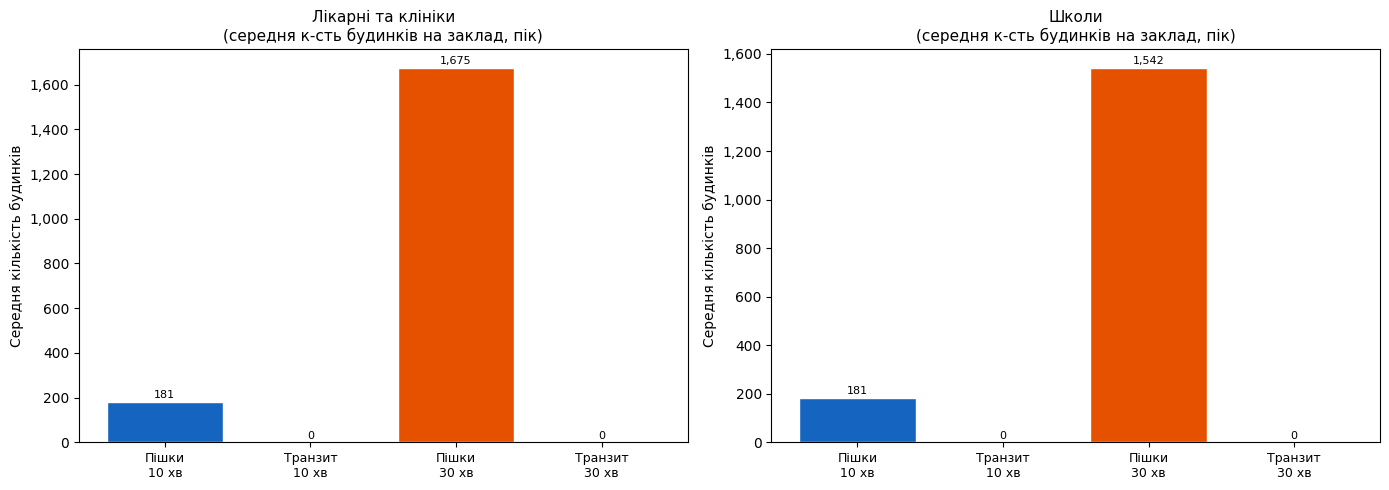


Графік збережено: outputs/15_catchment_groups.png
Notebook 07 (Секції 5–6) виконано. Далі — Секція 7: інтерактивна карта.


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

OUT_CSV = '../data/processed/catchment_results.csv'

# Завжди читаємо свіжий catchment_results.csv з диска,
# щоб не перезаписати його старим DataFrame з пам'яті kernel.
if not os.path.exists(OUT_CSV):
    raise FileNotFoundError(
        f'{OUT_CSV} не знайдено.\n'
        'Спочатку запустіть 07c_catchment_calc.ipynb'
    )
catchment_df = pd.read_csv(OUT_CSV)
print(f'catchment_df завантажено з диска: {len(catchment_df)} рядків')

print(f'Колонки: {list(catchment_df.columns)}')


# ── Змінні для зручності ──────────────────────────────────────────────────────
COL_PK_SH  = f'peak_total_{T_SHORT}min'
COL_PK_LG  = f'peak_total_{T_LONG}min'
COL_OP_SH  = f'offpeak_total_{T_SHORT}min'
COL_OP_LG  = f'offpeak_total_{T_LONG}min'

hosp  = catchment_df[catchment_df['facility_type'] == 'hospital']
school = catchment_df[catchment_df['facility_type'] == 'school']

# ── Середні значення по типах ─────────────────────────────────────────────────
print(f'\n{"─"*60}')
print(f'{"Метрика":<38} {"Лікарні":>10} {"Школи":>10}')
print(f'{"─"*60}')
for col, label in [
    (COL_PK_SH,  f'peak_total_{T_SHORT}min (буд.)'),
    (COL_PK_LG,  f'peak_total_{T_LONG}min (буд.)'),
    (COL_OP_SH,  f'offpeak_total_{T_SHORT}min (буд.)'),
    (COL_OP_LG,  f'offpeak_total_{T_LONG}min (буд.)'),
]:
    h_mean  = hosp[col].mean()
    s_mean  = school[col].mean()
    print(f'{label:<38} {h_mean:>10.0f} {s_mean:>10.0f}')

print(f'{"─"*60}')

# ── Заклади з нульовою короткою доступністю ───────────────────────────────────
zero_sh = (catchment_df[COL_PK_SH] == 0).sum()
print(f'\nЗакладів з {COL_PK_SH} = 0: {zero_sh} '
      f'({100*zero_sh/len(catchment_df):.1f}%)')

# ── Топ-5 і антитоп-5 за peak_total_30min ────────────────────────────────────
print(f'\n{"─"*60}')
print(f'Топ-5 закладів за {COL_PK_LG}:')
top5 = catchment_df.nlargest(5, COL_PK_LG)[['name', 'facility_type', COL_PK_LG]]
for _, r in top5.iterrows():
    print(f'  {str(r["name"])[:45]:<45}  {r["facility_type"][:5]}  {r[COL_PK_LG]:>6.0f}')

print(f'\nАнтитоп-5 закладів за {COL_PK_LG}:')
bot5 = catchment_df.nsmallest(5, COL_PK_LG)[['name', 'facility_type', COL_PK_LG]]
for _, r in bot5.iterrows():
    print(f'  {str(r["name"])[:45]:<45}  {r["facility_type"][:5]}  {r[COL_PK_LG]:>6.0f}')

# ── Візуалізація: порівняльна діаграма ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, facility_type, label, color in [
    (axes[0], 'hospital', 'Лікарні та клініки', '#2196F3'),
    (axes[1], 'school',   'Школи',              '#4CAF50'),
]:
    sub = catchment_df[catchment_df['facility_type'] == facility_type]
    cols = [
        f'peak_{GRP_WALK_SHORT}',    f'peak_{GRP_TRANSIT_SHORT}',
        f'peak_{GRP_WALK_LONG}',     f'peak_{GRP_TRANSIT_LONG}',
    ]
    means = sub[cols].mean()
    bar_colors = ['#1565C0', '#42A5F5', '#E65100', '#FFCC80']
    ax.bar(range(len(cols)), means.values, color=bar_colors, edgecolor='white')
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([
        f'Пішки\n{T_SHORT} хв', f'Транзит\n{T_SHORT} хв',
        f'Пішки\n{T_LONG} хв',  f'Транзит\n{T_LONG} хв',
    ], fontsize=9)
    ax.set_title(f'{label}\n(середня к-сть будинків на заклад, пік)', fontsize=11)
    ax.set_ylabel('Середня кількість будинків')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for i, v in enumerate(means.values):
        ax.text(i, v + max(means)*0.01, f'{int(v):,}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/15_catchment_groups.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nГрафік збережено: outputs/15_catchment_groups.png')
print('Notebook 07 (Секції 5–6) виконано. Далі — Секція 7: інтерактивна карта.')

## Секція 7а: Підготовка даних для інтерактивної карти

Формуємо JSON-структуру `map_data.json`, яка буде вбудована в HTML-карту (Секція 7б).

**Вхідні файли (створюються Секціями 1–5):**
- `data/processed/catchment_results.csv` — агрегована статистика по закладах
- `data/processed/catchment_buildings.parquet` — прив'язка будинків до закладів з групами
- `data/processed/buildings.parquet` — координати будинків (центроїди, EPSG:32636)

**Структура JSON на заклад:**
```json
{
  "id": "H0", "name": "...", "type": "hospital",
  "lat": 50.45, "lon": 30.52,
  "stats": { "peak_short": 120, "peak_long": 450, ... },
  "buildings": [{"lat": ..., "lon": ..., "group_peak": "walk_10min", ...}, ...]
}
```

**Результат:** `data/processed/map_data.json`

In [8]:
import json
from tqdm.auto import tqdm
from utils.catchment_map_export import export_catchment_map_data

# ── Відновлення конфігу якщо клітинка виконується окремо ─────────────────────
if 'cfg' not in vars():
    from config_loader import cfg

T_SHORT = cfg['catchment']['threshold_short_min']   # 10
T_LONG  = cfg['catchment']['threshold_long_min']    # 30

GRP_WALK_SHORT    = f'walk_{T_SHORT}min'
GRP_TRANSIT_SHORT = f'transit_{T_SHORT}min'
GRP_WALK_LONG     = f'walk_{T_LONG}min'
GRP_TRANSIT_LONG  = f'transit_{T_LONG}min'

# ── Перевірка наявності обов'язкових файлів ───────────────────────────────────
_REQUIRED = {
    'catchment_results':   '../data/processed/catchment_results.csv',
    'catchment_buildings': '../data/processed/catchment_buildings.parquet',
    'buildings':           '../data/processed/buildings.parquet',
}
_missing = [k for k, p in _REQUIRED.items() if not os.path.exists(p)]
if _missing:
    raise FileNotFoundError(
        f"Відсутні файли: {_missing}\n"
        'Запустіть Секції 1–5 — вони створять ці файли автоматично.'
    )

# ── Завантаження даних ────────────────────────────────────────────────────────
print('Завантаження даних...')
catchment_results   = pd.read_csv('../data/processed/catchment_results.csv')
catchment_buildings = pd.read_parquet('../data/processed/catchment_buildings.parquet')
buildings           = gpd.read_parquet('../data/processed/buildings.parquet')
scores              = pd.read_csv('../data/processed/accessibility_scores.csv')

facilities = scores[['facility_id', 'facility_type', 'name', 'lat', 'lon']].copy()

print(f'  catchment_results:   {len(catchment_results)} закладів')
print(f'  catchment_buildings: {len(catchment_buildings):,} записів')
print(f'  buildings:           {len(buildings):,} будинків')
print(f'  facilities:          {len(facilities)} закладів')

OUT_JSON = '../data/processed/map_data.json'
OUT_GEOJSON_DIR = '../data/processed/map_buildings'
HTML_REL_GEOJSON_DIR = '../data/processed/map_buildings'

payload = export_catchment_map_data(
    catchment_results=catchment_results,
    catchment_buildings=catchment_buildings,
    buildings=buildings,
    facilities=facilities,
    output_json_path=OUT_JSON,
    output_geojson_dir=OUT_GEOJSON_DIR,
    html_rel_geojson_dir=HTML_REL_GEOJSON_DIR,
    t_short=T_SHORT,
    t_long=T_LONG,
    grp_walk_short=GRP_WALK_SHORT,
    grp_transit_short=GRP_TRANSIT_SHORT,
    grp_walk_long=GRP_WALK_LONG,
    grp_transit_long=GRP_TRANSIT_LONG,
)

_json_mb = os.path.getsize(OUT_JSON) / 1_048_576
print(f'\nJSON збережено: {OUT_JSON}')
print(f'  Закладів:        {len(payload["facilities"])}')
print(f'  Будинків всього: {payload["_total_buildings"]:,}')
print(f'  Розмір файлу:    {_json_mb:.1f} MB')
print(f'  GeoJSON-каталог: {payload["_geojson_dir"]}')
print('\nДалі — Секція 7б: інтерактивна HTML-карта з метаданими закладів.')


ImportError: attempted relative import with no known parent package

## Секція 7б: Базова карта folium — маркери закладів

Будуємо folium-карту з маркерами лікарень і шкіл.
Будинки на цьому етапі не відображаємо — тільки заклади з попапами.

**Шари:**
- ⚕ Лікарні (червоний маркер)
- 📚 Школи (синій маркер)

**Попап при кліку на заклад:**
- Назва, тип
- Кількість будинків за 10 і 30 хв (пік / міжпік)
- Кнопка "Показати будинки" — підготовка до Секції 7в

**Вхідний файл:** `data/processed/map_data.json` (Секція 7а)
**Результат:** `outputs/map_temp.html`

In [22]:
import json
import folium

# ── Відновлення конфігу якщо клітинка виконується окремо ─────────────────────
if 'cfg' not in vars():
    from config_loader import cfg

T_SHORT = cfg['catchment']['threshold_short_min']   # 10
T_LONG  = cfg['catchment']['threshold_long_min']    # 30

# ── Завантаження JSON-даних (створюється Секцією 7а) ──────────────────────────
MAP_DATA_PATH = '../data/processed/map_data.json'

if not os.path.exists(MAP_DATA_PATH):
    raise FileNotFoundError(
        f'Файл {MAP_DATA_PATH} не знайдено.\n'
        'Спочатку запустіть Секцію 7а — вона створює цей файл.'
    )

with open(MAP_DATA_PATH, encoding='utf-8') as f:
    map_data = json.load(f)

print(f'Завантажено закладів: {len(map_data["facilities"])}')
print(f'T_SHORT={map_data["t_short"]} хв  |  T_LONG={map_data["t_long"]} хв')

# ── Ініціалізація карти ───────────────────────────────────────────────────────
m = folium.Map(
    location=[cfg['city']['center_lat'], cfg['city']['center_lon']],
    zoom_start=11,
    tiles='CartoDB positron'
)

# ── Шари для лікарень і шкіл ─────────────────────────────────────────────────
layer_hospitals = folium.FeatureGroup(name='⚕ Лікарні', show=True)
layer_schools   = folium.FeatureGroup(name='📚 Школи',  show=True)

# ── Цикл по закладах: додаємо маркер для кожного ─────────────────────────────
for fac in map_data['facilities']:
    is_hosp = fac['type'] == 'hospital'
    color   = '#C0392B' if is_hosp else '#2980B9'   # темно-червоний / синій
    icon    = '⚕'       if is_hosp else '📚'
    layer   = layer_hospitals if is_hosp else layer_schools

    # HTML попапу — статистика + кнопка (функція showBuildings додасться в 7в)
    popup_html = f"""
    <div style="width:230px;font-family:Arial,sans-serif;font-size:13px">
      <b style="font-size:14px">{fac['name'][:55]}</b><br>
      <span style="color:#666">{'Лікарня' if is_hosp else 'Школа'}</span>
      <hr style="margin:6px 0">
      <b>&#x1F552; Пік (07-09, 17-19):</b><br>
      &nbsp;За {T_SHORT} хв: <b>{fac['stats']['peak_short']:,}</b> буд.<br>
      &nbsp;За {T_LONG} хв: <b>{fac['stats']['peak_long']:,}</b> буд.
      <hr style="margin:6px 0">
      <b>&#x1F552; Міжпік (09-16):</b><br>
      &nbsp;За {T_SHORT} хв: <b>{fac['stats']['offpeak_short']:,}</b> буд.<br>
      &nbsp;За {T_LONG} хв: <b>{fac['stats']['offpeak_long']:,}</b> буд.
      <hr style="margin:6px 0">
      <button onclick="showBuildings('{fac['id']}')"
              style="width:100%;padding:5px 0;background:{color};
                     color:white;border:none;border-radius:4px;
                     cursor:pointer;font-size:12px">
        Показати будинки
      </button>
    </div>
    """

    # DivIcon: символ на кольоровому тлі → компактний маркер
    marker_html = (
        f'<div style="'
        f'background:{color};color:white;'
        f'border-radius:50%;width:24px;height:24px;'
        f'display:flex;align-items:center;justify-content:center;'
        f'font-size:13px;box-shadow:0 1px 3px rgba(0,0,0,.4);'
        f'border:2px solid white">'
        f'{icon}</div>'
    )

    folium.Marker(
        location=[fac['lat'], fac['lon']],
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{icon} {fac['name'][:40]}",
        icon=folium.DivIcon(
            html=marker_html,
            icon_size=(24, 24),
            icon_anchor=(12, 12),
        ),
    ).add_to(layer)

# ── Додаємо шари і керування ─────────────────────────────────────────────────
layer_hospitals.add_to(m)
layer_schools.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# ── Проміжне збереження ───────────────────────────────────────────────────────
OUT_HTML = '../outputs/map_temp.html'
m.save(OUT_HTML)

_n_hosp   = sum(1 for f in map_data['facilities'] if f['type'] == 'hospital')
_n_school = sum(1 for f in map_data['facilities'] if f['type'] == 'school')

print(f'\nКарту збережено: {OUT_HTML}')
print(f'  ⚕ Лікарні:  {_n_hosp}')
print(f'  📚 Школи:   {_n_school}')
print('\nДалі — Секція 7в: додаємо будинки та JS-перемикач пік/міжпік.')

Завантажено закладів: 1231
T_SHORT=10 хв  |  T_LONG=30 хв

Карту збережено: ../outputs/map_temp.html
  ⚕ Лікарні:  664
  📚 Школи:   567

Далі — Секція 7в: додаємо будинки та JS-перемикач пік/міжпік.


## Секція 7в: JavaScript-інтерактивність — будинки та перемикач

Розширюємо карту з Секції 7б: вбудовуємо JSON-дані в HTML і додаємо Leaflet-логіку через `branca.element.Element`.

**Що додається:**
- JSON всіх закладів і будинків — вбудований прямо в HTML (не потрібен сервер)
- `showBuildings(id)` — відображає будинки обраного закладу кольоровими точками (`CircleMarker`)
- `setMode('peak' | 'offpeak')` — перемикає кольори будинків між піком і міжпіком
- Перемикач **Пік / Міжпік** у правому верхньому куті (фіксований `position:fixed`)
- Легенда груп у правому нижньому куті

**Кольорова схема будинків:**

| Група | Колір |
|---|---|
| Пішки ≤ T_SHORT хв | `#2ECC71` яскраво-зелений |
| Транспорт ≤ T_SHORT хв | `#27AE60` темно-зелений |
| Пішки ≤ T_LONG хв | `#F39C12` помаранчевий |
| Транспорт ≤ T_LONG хв | `#E67E22` темно-помаранчевий |

**Вхідний файл:** `data/processed/map_data.json` (Секція 7а)
**Результат:** `outputs/map_catchment_interactive.html`

In [23]:
import json
import folium
from branca.element import Element

# ── Відновлення конфігу ───────────────────────────────────────────────────────
if 'cfg' not in vars():
    from config_loader import cfg

T_SHORT = cfg['catchment']['threshold_short_min']   # 10
T_LONG  = cfg['catchment']['threshold_long_min']    # 30

# ── Завантаження JSON (створюється Секцією 7а) ────────────────────────────────
MAP_DATA_PATH = '../data/processed/map_data.json'

if not os.path.exists(MAP_DATA_PATH):
    raise FileNotFoundError(
        f"Файл {MAP_DATA_PATH} не знайдено.\n"
        'Запустіть Секцію 7а — вона створює цей файл.'
    )

with open(MAP_DATA_PATH, encoding='utf-8') as f:
    map_data = json.load(f)

# Назви груп беремо з JSON (залежать від config.toml)
grp_walk_short    = map_data['grp_walk_short']
grp_transit_short = map_data['grp_transit_short']
grp_walk_long     = map_data['grp_walk_long']
grp_transit_long  = map_data['grp_transit_long']

print(f'Завантажено {len(map_data["facilities"])} закладів')

# ── Будуємо карту ─────────────────────────────────────────────────────────────
m = folium.Map(
    location=[cfg['city']['center_lat'], cfg['city']['center_lon']],
    zoom_start=11,
    tiles='CartoDB positron'
)

layer_hospitals = folium.FeatureGroup(name='⚕ Лікарні', show=True)
layer_schools   = folium.FeatureGroup(name='📚 Школи',  show=True)

for fac in map_data['facilities']:
    is_hosp = fac['type'] == 'hospital'
    color   = '#C0392B' if is_hosp else '#2980B9'
    icon    = '⚕' if is_hosp else '📚'
    layer   = layer_hospitals if is_hosp else layer_schools

    popup_html = (
        f"<div style='width:230px;font-family:Arial,sans-serif;font-size:13px'>"
        f"<b style='font-size:14px'>{fac['name'][:55]}</b><br>"
        f"<span style='color:#666'>{'Лікарня' if is_hosp else 'Школа'}</span>"
        f"<hr style='margin:6px 0'>"
        f"<b>&#x1F552; Пік (07-09, 17-19):</b><br>"
        f"&nbsp;За {T_SHORT} хв: <b>{fac['stats']['peak_short']:,}</b> буд.<br>"
        f"&nbsp;За {T_LONG} хв: <b>{fac['stats']['peak_long']:,}</b> буд."
        f"<hr style='margin:6px 0'>"
        f"<b>&#x1F552; Міжпік (09-16):</b><br>"
        f"&nbsp;За {T_SHORT} хв: <b>{fac['stats']['offpeak_short']:,}</b> буд.<br>"
        f"&nbsp;За {T_LONG} хв: <b>{fac['stats']['offpeak_long']:,}</b> буд."
        f"<hr style='margin:6px 0'>"
        f"<button onclick='showBuildings(\"{fac['id']}\")' "
        f"style='width:100%;padding:5px 0;background:{color};color:white;"
        f"border:none;border-radius:4px;cursor:pointer;font-size:12px'>"
        f"Показати будинки"
        f"</button>"
        f"</div>"
    )

    marker_html = (
        f'<div style="background:{color};color:white;'
        f'border-radius:50%;width:24px;height:24px;'
        f'display:flex;align-items:center;justify-content:center;'
        f'font-size:13px;box-shadow:0 1px 3px rgba(0,0,0,.4);'
        f'border:2px solid white">{icon}</div>'
    )

    folium.Marker(
        location=[fac['lat'], fac['lon']],
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{icon} {fac['name'][:40]}",
        icon=folium.DivIcon(
            html=marker_html, icon_size=(24, 24), icon_anchor=(12, 12)
        ),
    ).add_to(layer)

layer_hospitals.add_to(m)
layer_schools.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

map_var = m.get_name()

js_code = f"""
const MAP_DATA = {json.dumps(map_data, ensure_ascii=False)};

const COLORS = {{
    '{grp_walk_short}':    '#1FFF2E',
    '{grp_transit_short}': '#EB9328',
    '{grp_walk_long}':     '#1B6B23',
    '{grp_transit_long}':  '#FF0000',
}};

let currentMode = 'peak';
let buildingsLayer = null;
let currentFacilityId = null;
const facilityBuildingsCache = {{}};

function getMapObject() {{
    return {map_var};
}}

function renderFacilityBuildings(facilityId, geojson) {{
    const map = getMapObject();
    if (!map) return;

    if (buildingsLayer) map.removeLayer(buildingsLayer);

    const features = (geojson && geojson.features) ? geojson.features : [];
    buildingsLayer = L.layerGroup();

    features.forEach(feature => {{
        const props = feature.properties || {{}};
        const coords = feature.geometry && feature.geometry.coordinates;
        if (!coords || coords.length < 2) return;

        const group = currentMode === 'peak' ? props.group_peak : props.group_offpeak;
        if (!group) return;
        const color = COLORS[group] || '#BDC3C7';

        L.circleMarker([coords[1], coords[0]], {{
            radius: 3,
            color: color,
            fillColor: color,
            fillOpacity: 0.8,
            weight: 0,
        }}).addTo(buildingsLayer);
    }});

    buildingsLayer.addTo(map);
}}

async function showBuildings(facilityId) {{
    currentFacilityId = facilityId;
    const facility = MAP_DATA.facilities.find(f => f.id === facilityId);
    if (!facility) return;

    if (facilityBuildingsCache[facilityId]) {{
        renderFacilityBuildings(facilityId, facilityBuildingsCache[facilityId]);
        return;
    }}

    try {{
        const response = await fetch(facility.buildings_geojson);
        if (!response.ok) throw new Error('HTTP ' + response.status);
        const geojson = await response.json();
        facilityBuildingsCache[facilityId] = geojson;
        renderFacilityBuildings(facilityId, geojson);
    }} catch (err) {{
        console.error('Не вдалося завантажити GeoJSON будинків:', facilityId, err);
        alert('Не вдалося завантажити будинки для цього закладу. Відкрий карту через локальний сервер.');
    }}
}}

function setMode(mode) {{
    currentMode = mode;

    const btnPeak = document.getElementById('btn-peak');
    const btnOffpeak = document.getElementById('btn-offpeak');

    if (mode === 'peak') {{
        btnPeak.style.fontWeight = 'bold';
        btnPeak.style.opacity = '1';
        btnOffpeak.style.fontWeight = 'normal';
        btnOffpeak.style.opacity = '0.65';
    }} else {{
        btnOffpeak.style.fontWeight = 'bold';
        btnOffpeak.style.opacity = '1';
        btnPeak.style.fontWeight = 'normal';
        btnPeak.style.opacity = '0.65';
    }}

    if (currentFacilityId) showBuildings(currentFacilityId);
}}
"""

switcher_html = """
<div id="mode-switcher"
     style="position:fixed;top:10px;right:10px;z-index:1000;
            background:white;padding:8px 12px;border-radius:6px;
            box-shadow:0 2px 6px rgba(0,0,0,0.3);
            font-family:Arial,sans-serif;line-height:1.6">
  <b style="font-size:13px">Час доби:</b><br>
  <button id="btn-peak" onclick="setMode('peak')"
          style="margin:3px 2px;padding:5px 10px;
                 background:#E74C3C;color:white;
                 border:none;border-radius:4px;cursor:pointer;
                 font-weight:bold;font-size:12px">
    🔴 Пік (07-09, 17-19)
  </button><br>
  <button id="btn-offpeak" onclick="setMode('offpeak')"
          style="margin:3px 2px;padding:5px 10px;
                 background:#3498DB;color:white;
                 border:none;border-radius:4px;cursor:pointer;
                 opacity:0.65;font-size:12px">
    🔵 Міжпік (09-16)
  </button>
</div>
"""

legend_html = f"""
<div style="position:fixed;bottom:30px;right:10px;z-index:1000;
            background:white;padding:10px 14px;border-radius:6px;
            box-shadow:0 2px 6px rgba(0,0,0,0.3);
            font-family:Arial,sans-serif;font-size:12px;line-height:1.8">
  <b>Доступність будинків:</b><br>
  <span style="color:#1FFF2E;font-size:18px;vertical-align:middle">●</span>
  &nbsp;Пішки &#8804; {T_SHORT} хв<br>
  <span style="color:#EB9328;font-size:18px;vertical-align:middle">●</span>
  &nbsp;Транспорт &#8804; {T_SHORT} хв<br>
  <span style="color:#1B6B23;font-size:18px;vertical-align:middle">●</span>
  &nbsp;Пішки &#8804; {T_LONG} хв<br>
  <span style="color:#FF0000;font-size:18px;vertical-align:middle">●</span>
  &nbsp;Транспорт &#8804; {T_LONG} хв
</div>
"""

m.get_root().script.add_child(Element(js_code))
m.get_root().html.add_child(Element(switcher_html))
m.get_root().html.add_child(Element(legend_html))

OUT_HTML = '../outputs/map_catchment_interactive.html'
m.save(OUT_HTML)

print(f'Інтерактивну карту збережено: {OUT_HTML}')
print('Будинки тепер підвантажуються по кліку як окремі GeoJSON-файли.')
print('Для fetch() відкривай карту через локальний HTTP-сервер, а не file://.')


Завантажено 1231 закладів
Інтерактивну карту збережено: ../outputs/map_catchment_interactive.html
Будинки тепер підвантажуються по кліку як окремі GeoJSON-файли.
Для fetch() відкривай карту через локальний HTTP-сервер, а не file://.
